In [721]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [722]:
students = pd.read_csv('student_performance_dataset.csv')

In [723]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             3000 non-null   int64  
 1   Gender                3000 non-null   object 
 2   Age                   3000 non-null   int64  
 3   StudyHours            2850 non-null   float64
 4   GPA                   2850 non-null   float64
 5   Attendance            2850 non-null   float64
 6   Participation         2850 non-null   float64
 7   AssignmentsCompleted  2850 non-null   float64
 8   ProjectsCompleted     2850 non-null   float64
 9   Extracurriculars      2241 non-null   object 
dtypes: float64(6), int64(2), object(2)
memory usage: 234.5+ KB


In [724]:
# academic performance and study habits is our aim
# extracurricular feature cannot help us to train that model

In [725]:
students.drop(columns = ['Extracurriculars'], inplace = True)

In [726]:
students[students.isnull().any(axis = 1)]

,StudentID,Gender,Age,StudyHours,GPA,Attendance,Participation,AssignmentsCompleted,ProjectsCompleted
0,1,Male,19,13.27,NaN,70.22,8.72,3.0,2.0
14,15,Female,24,7.98,0.06,89.49,5.50,3.0,NaN
32,33,Female,18,11.24,1.42,81.26,6.19,NaN,1.0
35,36,Male,20,6.22,NaN,70.72,0.39,9.0,4.0
37,38,Male,21,13.07,0.88,NaN,0.95,8.0,3.0
...,...,...,...,...,...,...,...,...,...
2985,2986,Female,18,1.39,NaN,95.31,0.46,16.0,NaN
2986,2987,Female,18,1.51,1.88,NaN,2.03,0.0,2.0
2994,2995,Female,24,14.33,NaN,96.20,6.06,12.0,3.0
2997,2998,Male,23,13.41,0.50,NaN,0.17,10.0,3.0


In [727]:
students = students[students.isnull().sum(axis = 1) <= 1]

In [728]:
students.shape

(2894, 9)

## Hanlding Missing Values

In [729]:
students.columns

Index(['StudentID', 'Gender', 'Age', 'StudyHours', 'GPA', 'Attendance',
       'Participation', 'AssignmentsCompleted', 'ProjectsCompleted'],
      dtype='object')

In [730]:
num_cols = ['StudyHours', 'GPA', 'Attendance', 'Participation', 'AssignmentsCompleted', 'ProjectsCompleted']

cat_cols = ['Gender']

In [731]:
students[num_cols].describe()

,StudyHours,GPA,Attendance,Participation,AssignmentsCompleted,ProjectsCompleted
count,2780.000000,2785.000000,2775.000000,2784.000000,2777.000000,2781.000000
mean,7.378773,2.029566,75.064342,5.004960,9.572200,2.072276
std,4.355361,1.147749,14.417915,2.865266,5.796183,1.418591
min,0.000000,0.010000,50.010000,0.000000,0.000000,0.000000
25%,3.597500,1.060000,62.835000,2.530000,5.000000,1.000000
50%,7.380000,2.050000,75.070000,5.020000,9.000000,2.000000
75%,11.190000,3.020000,87.420000,7.430000,15.000000,3.000000
max,15.000000,4.000000,99.980000,10.000000,19.000000,4.000000


## Imputations

In [732]:
for col in num_cols:
    median = students[col].median()
    students[col].fillna(median, inplace = True)

C:\Users\Jakkala\AppData\Local\Temp\ipykernel_12740\3178715827.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  students[col].fillna(median, inplace = True)


In [733]:
students.isna().sum()

StudentID               0
Gender                  0
Age                     0
StudyHours              0
GPA                     0
Attendance              0
Participation           0
AssignmentsCompleted    0
ProjectsCompleted       0
dtype: int64

In [734]:
# no null values
# we should handle outleirs now

## Handling Outliers

In [735]:
students[num_cols].describe()

,StudyHours,GPA,Attendance,Participation,AssignmentsCompleted,ProjectsCompleted
count,2894.000000,2894.000000,2894.000000,2894.000000,2894.000000,2894.000000
mean,7.378822,2.030335,75.064575,5.005532,9.549067,2.069454
std,4.268686,1.125926,14.118270,2.810267,5.678887,1.390681
min,0.000000,0.010000,50.010000,0.000000,0.000000,0.000000
25%,3.772500,1.100000,63.375000,2.650000,5.000000,1.000000
50%,7.380000,2.050000,75.070000,5.020000,9.000000,2.000000
75%,11.020000,2.990000,86.977500,7.327500,15.000000,3.000000
max,15.000000,4.000000,99.980000,10.000000,19.000000,4.000000


In [736]:
for col in num_cols:
    q1 = students[col].quantile(0.25)
    q3 = students[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound  = q1 - iqr * 1.5
    upper_bound = q3 + iqr * 1.5
    outliers = students[(students[col] < lower_bound) | (students[col] > upper_bound)]
    print(f"No. of outliers in {col}: {outliers.shape[0]}")

No. of outliers in StudyHours: 0
No. of outliers in GPA: 0
No. of outliers in Attendance: 0
No. of outliers in Participation: 0
No. of outliers in AssignmentsCompleted: 0
No. of outliers in ProjectsCompleted: 0


In [737]:
for col in num_cols:
    print(f"Skewness of {col}: {students[col].skew()}")

Skewness of StudyHours: 0.01685708490379427
Skewness of GPA: -0.06437346579872182
Skewness of Attendance: -0.025301175440717406
Skewness of Participation: 0.013561266570718414
Skewness of AssignmentsCompleted: -0.0025903268730605657
Skewness of ProjectsCompleted: -0.0740481457889437


## Feature Engineering

In [738]:
students['ProductivityScore'] = (students['AssignmentsCompleted'] + students['ProjectsCompleted']) / (students['StudyHours'] + 1e-3)

In [739]:
students['ParticipationIntensity'] = students['Participation'] / (students['Attendance'] + 1e-3)

In [740]:
students['EfficiencyScore'] = students['GPA'] / (students['StudyHours'] + 1e-3)

In [741]:
students.isnull().sum()

StudentID                 0
Gender                    0
Age                       0
StudyHours                0
GPA                       0
Attendance                0
Participation             0
AssignmentsCompleted      0
ProjectsCompleted         0
ProductivityScore         0
ParticipationIntensity    0
EfficiencyScore           0
dtype: int64

## Data Transformation

In [742]:
num_cols = num_cols + ['ProductivityScore', 'ParticipationIntensity', 'EfficiencyScore']

In [743]:
for col in num_cols:
    print(f"Skewness of {col}: {students[col].skew()}")

Skewness of StudyHours: 0.01685708490379427
Skewness of GPA: -0.06437346579872182
Skewness of Attendance: -0.025301175440717406
Skewness of Participation: 0.013561266570718414
Skewness of AssignmentsCompleted: -0.0025903268730605657
Skewness of ProjectsCompleted: -0.0740481457889437
Skewness of ProductivityScore: 52.48037539765437
Skewness of ParticipationIntensity: 0.3540791807979957
Skewness of EfficiencyScore: 49.35973655238282


In [744]:
students['EfficiencyScore'] = np.log1p(students['EfficiencyScore'])
students['ProductivityScore'] = np.log1p(students['ProductivityScore'])

In [745]:
print("Skewness of EfficiencyScore:", students['EfficiencyScore'].skew())
print("Skewness of ProductivityScore:", students['ProductivityScore'].skew())

Skewness of EfficiencyScore: 4.183957735193298
Skewness of ProductivityScore: 2.3149967911436464


In [746]:
# features are close to normal distribution
# there is no need to transform them further

## Elbow Method

In [747]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

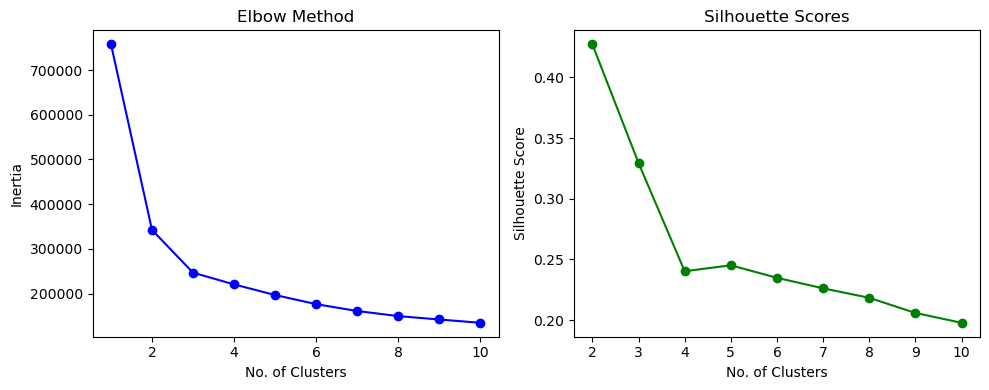

In [748]:
x = students[num_cols] 

inertia = []
silhouette_scores = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x)
    inertia.append(kmeans.inertia_)

    if k > 1:
        silhouette_scores.append(silhouette_score(x, kmeans.labels_))
    else:
        silhouette_scores.append(None)

#Elbow Curve
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(K, inertia, color = 'blue', marker = 'o', linestyle = '-')
plt.xlabel('No. of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K[1:], silhouette_scores[1:], color = 'green', marker = 'o', linestyle = '-')
plt.xlabel('No. of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.tight_layout()
plt.show()


In [749]:
#inertia is sum of squared errors
# the elbow is at 3 clusters

In [750]:
# highest silhoutte score is at 2
# 2, 3 have good silhoutte scores

In [751]:
# clusters are more well seperated with 2 number of clusters ( from silhoutte score)
# so we will choose the number of clusters value as 2

## Data Scaling, One-Hot Encoding Pipeline

In [752]:
selected_features = [ 'StudyHours', 'GPA', 'Attendance', 'Gender', 'Participation', 'AssignmentsCompleted', 'ProjectsCompleted', 'EfficiencyScore', 'ParticipationIntensity', 'ProductivityScore']

In [753]:
num_features = ['StudyHours', 'GPA', 'Attendance', 'Participation', 'AssignmentsCompleted', 'ProjectsCompleted', 'EfficiencyScore', 'ParticipationIntensity', 'ProductivityScore']

cat_features = ['Gender']

In [754]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans 

In [755]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder( drop = 'first')

In [756]:
preprocessor = ColumnTransformer(transformers = [
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

In [757]:
pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('clustering', KMeans(n_clusters = 2, random_state = 44))
])

In [758]:
x = students[selected_features]

In [759]:
pipeline.fit(x)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['StudyHours', 'GPA',
                                                   'Attendance',
                                                   'Participation',
                                                   'AssignmentsCompleted',
                                                   'ProjectsCompleted',
                                                   'ProductivityScore',
                                                   'ParticipationIntensity',
                                                   'EfficiencyScore']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Gender'])])),
                ('clustering', KMeans(n_clusters=2, random_state=44))])

In [760]:
students['Cluster'] = pipeline.named_steps['clustering'].labels_

## Model Evaluation

In [761]:
students['Cluster'].value_counts()

Cluster
0    2260
1     634
Name: count, dtype: int64

In [762]:
students.groupby('Cluster')[num_cols].mean()

,StudyHours,GPA,Attendance,Participation,AssignmentsCompleted,ProjectsCompleted,ProductivityScore,ParticipationIntensity,EfficiencyScore
Cluster,,,,,,,,,
0,8.916336,1.943106,74.895796,5.117128,9.033186,2.031416,0.820373,0.070959,0.217936
1,1.898091,2.341278,75.666215,4.607729,11.388013,2.205047,2.377444,0.063342,1.070667


In [763]:
# students with high gpa have high productivity and high efficiency

In [764]:
from sklearn.metrics import silhouette_score

x_transformed = pipeline.named_steps['preprocessor'].transform(x)
labels = pipeline.named_steps['clustering'].labels_

sil_score = silhouette_score(x_transformed, labels)
print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.213


In [765]:
# the model has better silhoutte score when we use 2 clusters compared to 3 clusters

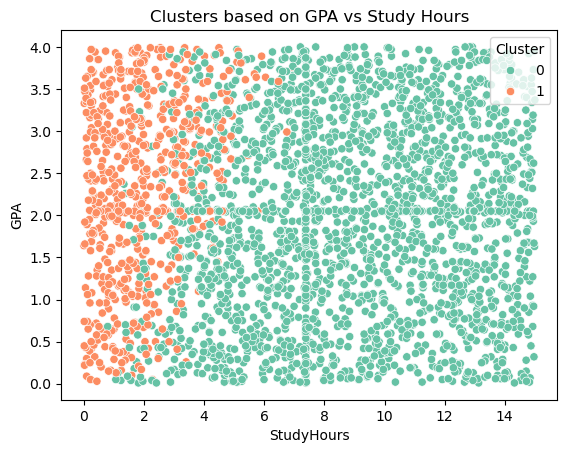

In [766]:
# GPA vs StudyHours
sns.scatterplot(data=students, x='StudyHours', y='GPA', hue='Cluster', palette='Set2')
plt.title("Clusters based on GPA vs Study Hours")
plt.show()

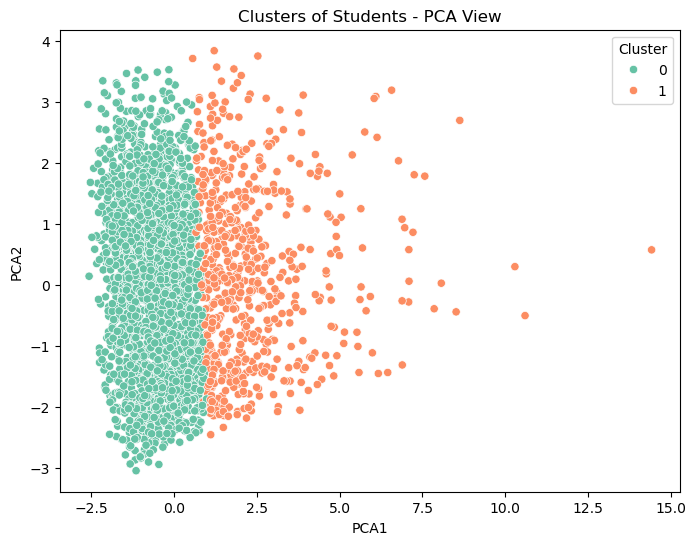

In [767]:
# Apply preprocessing separately for PCA
X_preprocessed = preprocessor.fit_transform(students)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_preprocessed)

students['PCA1'] = X_pca[:, 0]
students['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=students, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('Clusters of Students - PCA View')
plt.show()